## Tools Setup

In [50]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds # 
from tiny_imagenet import TinyImagenetDataset #this is used for downloading subset of selected images from the 14 million total images
import math
from prettytable import PrettyTable
from matplotlib import pyplot
import seaborn as sns
import time


# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = True
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

Running on Python Version: 3.9.25 (main, Jul 13 2026, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Using Tensorflow Version: 2.16.2
Using GPU at: /device:GPU:0 (of 1 available)


2026-10-01 04:48:13.426614: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-01 04:48:13.430182: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-01 04:48:13.433821: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [51]:
#Load the model
model_path = os.path.abspath("CNN_TinyImageNet.h5")

model = tf.keras.models.load_model(model_path)
model.summary()

/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/umhaihl/machine_learning/lab4/python_stuff/lab4_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

-127
[-9, 3, 21, 39, 35, 14, -12, 32, -22, 15, -29, 2, 5, 46, -31, 27, 17, 34, -22, 7, -10, 6, 3, 29, -32, -23, 22, 4, -31, 4, -3, -9, -2, -38, 24, 40, 2, 13, 30, 4, 9, -17, 2, -32, 25, 4, -12, 21, 39, 0, -46, 2, -46, -14, 8, 4, -1, -16, -19, -11, 11, 32, -30, -19, -20, -28, 27, 22, 30, 2, 9, 29, -21, 16, 20, -28, 3, -14, -48, -17, 12, 38, -34, 22, -9, 41, 32, 9, -25, 36, 17, -17, 39, -29, -35, 35, 16, 29, 16, 40, 37, 7, -24, -2, 22, 12, -10, 30, 41, -13, -10, -1, 39, 33, 1, 27, -34, 10, -35, 19, -3, -32, 47, 2, -16, 17, -22, -31, 37, -12, -51, 34, -27, 22, 13, -67, 18, 38, -21, 5, 11, -22, -24, 39, 51, -3, -14, 18, -38, 42, -49, -38, -51, -13, -16, 20, -3, -32, -13, 27, 31, -31, -26, 4, 25, 47, -14, -111, 41, 50, 27, 25, 25, 16, 1, 25, 13, 27, -39, -19, -9, 38, -5, 19, -17, -8, 33, 32, -25, -21, -43, 6, 13, 22, 38, 15, -35, -6, -6, -43, 0, -47, -2, -22, 0, 7, -22, -56, 55, 8, -35, 48, -41, -56, -17, 21, -63, 20, -36, -6, 18, 37, -5, 27, 18, 12, 12, -26, 7, 13, 35, -23, -20, -4, 7, 18,

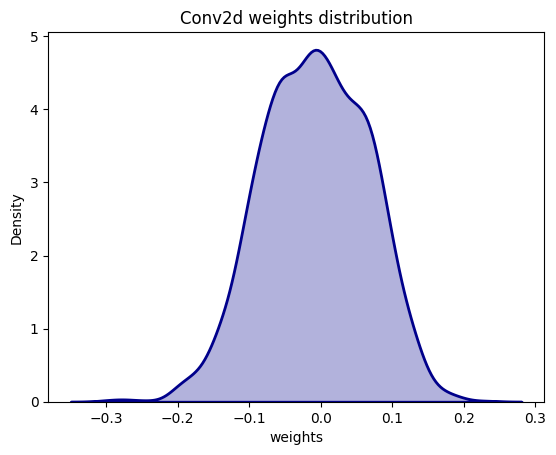

In [52]:
##############################  Weight Quantization  ###############################
#Export quantized weights
# Make a directory for our image data
model_dir = os.path.abspath('quantized_model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)

conv2d_layer_weights = model.layers[0].weights[0].numpy().flatten()

#calculating the max and the min weights for conv2d layer
conv2d_min_w = conv2d_layer_weights.min()
conv2d_max_w = conv2d_layer_weights.max()

#find the scaling factor for layer1
conv2d_Sw = 127/max(abs(conv2d_min_w), abs(conv2d_max_w)) 

#construct quantized weights array for conv2d
conv2d_quantized_weights = []
for d_weight in conv2d_layer_weights:
    conv2d_quantized_weights.append(round(conv2d_Sw * d_weight))

#Just for checking, to see if quantized_weights is correct
print(np.min(conv2d_quantized_weights))
print(conv2d_quantized_weights)
print(np.array(conv2d_quantized_weights, dtype=np.int8).tobytes())

#create a file for quantized weights and put them in there 
quantized_weight_file_name = os.path.join(model_dir, f'conv2d_quantized_weights.bin')

with open(quantized_weight_file_name, 'wb') as f:
    f.write(np.array(conv2d_quantized_weights, dtype=np.int8).tobytes())

#plotting the distrubution of weights for conv2d layer
sns.kdeplot(conv2d_layer_weights, color='darkblue', linewidth=2, fill=True, alpha=0.3)
plt.title("Conv2d weights distribution")
plt.xlabel("weights")
plt.show()

## Dataset Inspection

In [53]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

#so basically what this is: ImageNet is a massive amout of image data (over 14 million images) available, but since we don't want that much,
#we are just downloading a subset of them to train
tiny_imagenet_builder = TinyImagenetDataset() #make an instance of the class.

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset() # convert all the downlaoded things to datasets
ds_train, ds_val = ds["train"], ds["validation"] # ds["train"] is the dataset of images that are used for training
                                                 # ds["validation"] is the dataset of images that are used for validation
assert(isinstance(ds_train, tf.data.Dataset)) # make sure both ds_train and tf.data.Dataset have the correct type.
assert(isinstance(ds_val, tf.data.Dataset))# make sure both ds_train and tf.data.Dataset have the correct type.

# Training Dataset
ds_train = ds_train.prefetch(tf.data.AUTOTUNE) #shuffle the training set in chunks of 1024

# Validation Dataset
ds_val = ds_val.prefetch(tf.data.AUTOTUNE) #shuffle the validation set in chunks of 1024

# Dataset metadata
ds_info = tiny_imagenet_builder.info

[0.27450982 0.14509805 0.07058824 ... 0.9490196  0.74509805 0.6       ]
188.32248822866472
-61


2026-10-01 05:25:02.992985: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


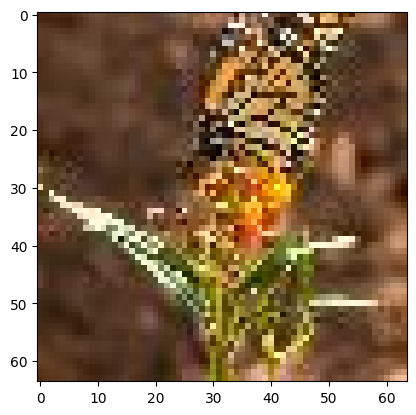

In [61]:
##############################  Input Quantization Parameteres  ###############################

#get the first picture of the train dataset and plot it to know we are doing good
img = next(iter(ds_train))

# convert the image array into fp32 to quantize it
image = img['image'].numpy().astype(np.float32) / 255.0

plt.figure()
plt.imshow(image)
# we could also recast it to uint8 first, but matplotlib supports both ways, so above line works fine as well
#plt.imshow(np.round(image * 255.0).astype(np.uint8))

# flatten the image so it is easier to work with
image_flatten = image.flatten()
print(image_flatten)

conv2d_max_i = image_flatten.max() #tested was 1
conv2d_min_i = image_flatten.min() #tested was 0
conv2d_avg_i = image_flatten.mean()

# get the scale factor for a single input for conv2d layer
conv2d_Si = 127 / max(abs(conv2d_min_i - conv2d_avg_i), abs(conv2d_max_i - conv2d_avg_i))
print(conv2d_Si)

# compute the offset 
conv2d_Zi = -1 * round(conv2d_Si * conv2d_avg_i)
print(conv2d_Zi)

In [62]:
##############################  Bias Quantizations  ###############################

#Export quantized weights
# Make a directory for our image data

# flatten all the biases
conv2d_layer_biases = model.layers[0].weights[1].numpy().flatten()

# make a list to store the quantized biases
conv2d_quantized_biases = []
for d_bias in conv2d_layer_biases:
    conv2d_quantized_biases.append(round(conv2d_Si * conv2d_Sw * d_bias))

# from the equation in my iPad, get the effective bias, where we merge all the leftover terms with the bias
conv2d_quantized_combined_biases = []

for d_quatized_bias in conv2d_quantized_biases:
    conv2d_quantized_combined_biases.append(d_quatized_bias - (conv2d_Zi * sum(conv2d_quantized_weights)))

print(conv2d_quantized_biases)
print(sum(conv2d_quantized_weights))


#create a file for quantized weights and put them in there 
quantized_biases_file_name = os.path.join(model_dir, f'conv2d_quantized_combined_biases.bin')

with open(quantized_biases_file_name, 'wb') as f:
    f.write(np.array(conv2d_quantized_combined_biases, dtype=np.int32).tobytes())

[654, 603, -582, 2377, 206, 3957, -2288, 2255, 3594, -3268, 1676, 806, 5348, 831, 2688, 1641, 2010, 93, -1800, -999, 988, -2323, 2069, 410, -639, 233, -1, -1031, 2234, 7708, -374, -4522]
-8395


In [63]:
########################## Import the Scaling Fators #########################
scaling_factors_text =  [
    f"conv2d_Sw : {conv2d_Sw}",
    f"conv2d_Si : {conv2d_Si}",
    f"conv2d_Zi : {conv2d_Zi}"
]

scaling_factors_info_file_name = os.path.join(model_dir, f'scaling_factors_info.txt')

with open(scaling_factors_info_file_name, "w", encoding="utf-8") as f:
    f.write("\n".join(scaling_factors_text))

In [67]:
########################## Import the Test Image #########################

# make a new directory for input_image and intermediate feature maps
input_dir = os.path.abspath('input_data')
pathlib.Path(input_dir).mkdir(exist_ok=True)


test_input_image_file_name = os.path.join(input_dir, f'test_input_image.bin')

with open(test_input_image_file_name, 'wb') as f:
    f.write(image_flatten.tobytes())

In [69]:
######################## Import the intermediate feature maps ####################

# make a new directory for intermediate feature maps
feature_maps_dir = os.path.abspath('test_input_feature_maps')
pathlib.Path(feature_maps_dir).mkdir(exist_ok=True)

#create a placeholder tensor
inp = tf.keras.Input(shape=(64, 64, 3))
x = inp             
outs = []     # array to hold all the intermediate output tensor

#model.layers is a list of Layer objects
#it is also callable as self funciton.
for layer in model.layers: #we want the intermediate results only so don't get the last layer which is flat
    x = layer(x)   #so when you call layer() it takes an input tensor and returns the output tensor
                   # which then we feed into the next layer
    outs.append(x) # we append each output to an array so we can see how our intermediate feature maps look like

feature_map_model = tf.keras.Model(inputs=inp, outputs=outs) #create a model. A clone of the loaded model but we can access intermediate feature maps

layer_names = [l.name for l in feature_map_model.layers]

batched_image = tf.expand_dims(image, axis=0)

pred = feature_map_model.predict(batched_image)

pred_layer_named_outs = dict(zip(layer_names[1:], pred)) # NOTE this is how to make a dict when one has names and the other values. zip them

for key, value in pred_layer_named_outs.items(): # NOTE had to put .items() since I am iterating over the itmes

    print(key)

    feaure_file_name = os.path.join(feature_maps_dir, f'{key}_feature.bin')

    with open(feaure_file_name, 'wb') as f:
        f.write(value.flatten().tobytes())

#making sure layer_names have the same length as output features
assert len(layer_names[1:]) == len(pred) 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
conv2d
conv2d_1
max_pooling2d
conv2d_2
conv2d_3
max_pooling2d_1
conv2d_4
conv2d_5
max_pooling2d_2
flatten
dense
dense_1
